In [1]:
!pip install git+https://github.com/drapado/d2l-wur.git
!pip install scipy --quiet
!pip install torchmetrics --quiet
!pip install torch-summary --quiet

  Cloning https://github.com/drapado/d2l-wur.git to /tmp/pip-req-build-irf20hsy
  Running command git clone --filter=blob:none --quiet https://github.com/drapado/d2l-wur.git /tmp/pip-req-build-irf20hsy
  Resolved https://github.com/drapado/d2l-wur.git to commit fe9e2db3f28092dc60ea8d317e72dd708f57cfb5
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.6 MB/s eta 0:00:00
  Created wheel for d2l: filename=d2l-1.0.3-py3-none-any.whl size=111669 sha256=89746e3d4240ea9122f6822e0500ecf63aea3f67229ab9b00b9e0cfc01c27ef9
  Stored in directory: /tmp/pip-ephem-wheel-cache-adj9dgg1/wheels/ea/d2/2e/f8b68fe88c17f8a47b9e7b1251059edfd0c4122db1e993b83e
Successfully built d2l
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.

In [2]:
%matplotlib inline
from d2l import torch as d2l
import torch
import torchvision
from torchvision.transforms import ToPILImage
from torch import nn
from torch.nn import functional as F
from PIL import ImageFile, Image
import matplotlib.pyplot as plt
from object_detection_utils import ResizeWithBBox, plot_bbox, plot_grid, box_xyxy_to_cxcywh, box_xywh_to_xyxy
import random
import cv2

# Download the dataset
First, let's download the dataset. It consists of images of plant, bounding box annotations, and leaf counts annotations.

In [3]:
!git clone https://git.wur.nl/abe-datasets/education/fruit-detection-challenge.git

Cloning into 'fruit-detection-challenge'...
remote: Enumerating objects: 2010, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 2010 (delta 2), reused 0 (delta 0), pack-reused 2004 (from 1)
Receiving objects: 100% (2010/2010), 255.89 MiB | 16.21 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Updating files: 100% (1958/1958), done.


## The COCO dataset format

The labels for this detection dataset are stored using the COCO JSON format. COCO JSON is a data format used for object detection, segmentation, and keypoint annotation in images. It includes metadata like image paths, annotations, categories, and licenses, typically structured into keys such as "images," "annotations," "categories," and more.

Example structure:
```json
{
  "images": [
    {
      "id": 1,
      "width": 640,
      "height": 480,
      "file_name": "image1.jpg",
      "license": 1,
      "date_captured": "2023-10-01"
    }
  ],
  "annotations": [
    {
      "id": 1,
      "image_id": 1,
      "category_id": 1,
      "bbox": [50, 70, 80, 60],
      "area": 4800,
      "segmentation": [[121.39,215.89,...]],
      "iscrowd": 0
    }
  ],
  "categories": [
    {
      "id": 1,
      "name": "cat",
      "supercategory": "animal"
    },
    {
      "id": 2,
      "name": "dog",
      "supercategory": "animal"
    }
  ]
}
```

Let's open the `train.json` file and explore it:

In [4]:
import json

json_path = "fruit-detection-challenge/detection/annotations/train.json"

with open(json_path, 'r') as f:
    data = json.load(f)

print(data.keys())
print(f"Number of images: {len(data['images'])}")
print(f"Number of annotations: {len(data['annotations'])}")
print(f"Number of categories: {len(data['categories'])}")
print(f"Categories: {data['categories']}")
print(f"Example image: {data['images'][0]}")
print(f"Example annotation: {data['annotations'][0]}")

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Number of images: 218
Number of annotations: 1603
Number of categories: 4
Categories: [{'id': 1, 'name': 'apple', 'supercategory': ''}, {'id': 2, 'name': 'banana', 'supercategory': ''}, {'id': 3, 'name': 'orange', 'supercategory': ''}, {'id': 4, 'name': 'pear', 'supercategory': ''}]
Example image: {'id': 1, 'file_name': 'scene 1_color_001.png', 'width': 1280, 'height': 720, 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': ''}
Example annotation: {'id': 1, 'image_id': 1, 'category_id': 2, 'bbox': [463.0, 197.0, 294.0, 282.0], 'area': 25736.5, 'iscrowd': 0, 'ignore': 0, 'segmentation': [[702.0, 200.0, 691.0, 197.0, 681.0, 198.0, 673.0, 206.0, 666.0, 223.0, 667.0, 233.0, 672.0, 240.0, 675.0, 242.0, 686.0, 243.0, 696.0, 254.0, 703.0, 268.0, 706.0, 280.0, 706.0, 288.0, 704.0, 293.0, 699.0, 300.0, 681.0, 338.0, 669.0, 354.0, 657.0, 365.0, 635.0, 380.0, 596.0, 398.0, 553.0, 410.0, 522.0, 416.0, 494.0, 429.0

In [5]:
import os
import random
from PIL import Image
from object_detection_utils import plot_bbox

json_path = "fruit-detection-challenge/detection/annotations/train.json"
image_folder = "fruit-detection-challenge/detection/train/"

with open(json_path, 'r') as f:
    data = json.load(f)

images = data['images']
random_image_info = random.choice(images) # Select a random image from the images list in JSON
image_id = random_image_info['id']
image_path = os.path.join(image_folder, random_image_info['file_name'])
print(f"Selected image: {image_path}")

img = Image.open(image_path)

boxes = []
labels = []

for annotation in data['annotations']:
    if annotation['image_id'] == image_id:
        bbox = annotation['bbox']
        x, y, w, h = bbox  # COCO box format is [x, y, width, height]
        center_x = x + w / 2.0
        center_y = y + h / 2.0
        boxes.append((center_x, center_y, w, h))
        labels.append(annotation['category_id'] - 1) # COCO category IDs start from 1, so we subtract 1 to make it zero-indexed

print(f"Boxes: {boxes}")
print(f"Labels: {labels}")

img_with_bboxes = plot_bbox(img.copy(), boxes, labels)
img_with_bboxes.show()

Selected image: fruit-detection-challenge/detection/train/scene 2_color_003.png
Boxes: [(442.0, 501.0, 236.0, 230.0), (557.5, 184.0, 279.0, 318.0), (656.0, 225.0, 192.0, 198.0), (629.0, 600.5, 172.0, 237.0), (731.0, 399.0, 186.0, 180.0), (913.0, 396.5, 142.0, 163.0), (827.5, 468.5, 153.0, 279.0)]
Labels: [0, 1, 0, 3, 2, 2, 3]


Let's explore the labels for the two-step method.

In [6]:
json_path = "fruit-detection-challenge/detection/annotations/train_one_class.json"

with open(json_path, 'r') as f:
    data = json.load(f)

print(data.keys())
print(f"Number of images: {len(data['images'])}")
print(f"Number of annotations: {len(data['annotations'])}")
print(f"Number of categories: {len(data['categories'])}")
print(f"Categories: {data['categories']}")
print(f"Example image: {data['images'][0]}")
print(f"Example annotation: {data['annotations'][0]}")

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Number of images: 218
Number of annotations: 1603
Number of categories: 1
Categories: [{'id': 1, 'name': 'fruit', 'supercategory': ''}]
Example image: {'id': 1, 'file_name': 'scene 1_color_001.png', 'width': 1280, 'height': 720, 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': ''}
Example annotation: {'id': 1, 'image_id': 1, 'category_id': 1, 'bbox': [463.0, 197.0, 294.0, 282.0], 'area': 25736.5, 'iscrowd': 0, 'ignore': 0, 'segmentation': [[702.0, 200.0, 691.0, 197.0, 681.0, 198.0, 673.0, 206.0, 666.0, 223.0, 667.0, 233.0, 672.0, 240.0, 675.0, 242.0, 686.0, 243.0, 696.0, 254.0, 703.0, 268.0, 706.0, 280.0, 706.0, 288.0, 704.0, 293.0, 699.0, 300.0, 681.0, 338.0, 669.0, 354.0, 657.0, 365.0, 635.0, 380.0, 596.0, 398.0, 553.0, 410.0, 522.0, 416.0, 494.0, 429.0, 487.0, 431.0, 477.0, 431.0, 468.0, 434.0, 465.0, 439.0, 463.0, 454.0, 467.0, 459.0, 491.0, 471.0, 506.0, 476.0, 522.0, 479.0, 562.0, 478.0, 595.0,

In [7]:
json_path = "fruit-detection-challenge/detection/annotations/train_one_class.json"
image_folder = "fruit-detection-challenge/detection/train/"

with open(json_path, 'r') as f:
    data = json.load(f)

images = data['images']
random_image_info = random.choice(images) # Select a random image from the images list in JSON
image_id = random_image_info['id']
image_path = os.path.join(image_folder, random_image_info['file_name'])
print(f"Selected image: {image_path}")

img = Image.open(image_path)

boxes = []
labels = []

for annotation in data['annotations']:
    if annotation['image_id'] == image_id:
        bbox = annotation['bbox']
        x, y, w, h = bbox  # COCO box format is [x, y, width, height]
        center_x = x + w / 2.0
        center_y = y + h / 2.0
        boxes.append((center_x, center_y, w, h))
        labels.append(annotation['category_id'] - 1) # COCO category IDs start from 1, so we subtract 1 to make it zero-indexed

print(f"Boxes: {boxes}")
print(f"Labels: {labels}")

img_with_bboxes = plot_bbox(img.copy(), boxes, labels)
img_with_bboxes.show()

Selected image: fruit-detection-challenge/detection/train/scene 5_color_071.png
Boxes: [(901.5, 233.0, 315.0, 222.0), (1041.0, 472.0, 212.0, 198.0), (319.0, 636.5, 142.0, 129.0), (1061.0, 260.5, 206.0, 187.0), (214.5, 640.0, 95.0, 88.0), (907.5, 372.5, 179.0, 167.0), (305.5, 707.5, 91.0, 23.0), (176.0, 713.0, 76.0, 12.0)]
Labels: [0, 0, 0, 0, 0, 0, 0, 0]


# The `Dataset` class from COCO json data
Now, let's create a dataset customized to our data.
We will call it `FruitDetectionDataset`. You need to define three methods (as you should aready know): the constructor `__init__`, `__get_item__` and `__len__`.

In [8]:
import json
import os
import torch

class FruitDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, json_path, img_folder, img_size, transforms=None):
        self.img_folder = img_folder
        self.transforms = transforms
        self.resize = ResizeWithBBox(img_size)

        with open(json_path, 'r') as f:
            coco_data = json.load(f)

        self.images = coco_data['images']
        self.annotations = coco_data['annotations']
        self.categories = coco_data['categories']

        self.category_id_to_index = {
            category['id']: idx for idx, category in enumerate(self.categories)
        }

        self.img_id_to_annotations = {}
        for annotation in self.annotations:
            img_id = annotation['image_id']
            if img_id not in self.img_id_to_annotations:
                self.img_id_to_annotations[img_id] = []
            self.img_id_to_annotations[img_id].append(annotation)

        self.max_boxes = max(len(v) for v in self.img_id_to_annotations.values())

        self.img_files = [
            os.path.join(img_folder, img['file_name']) for img in self.images
        ]

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        img_id = self.images[idx]['id']
        annotations = self.img_id_to_annotations.get(img_id, [])

        img = Image.open(img_path).convert("RGB")

        bboxes = []
        labels = []
        for annotation in annotations:
            x, y, width, height = annotation['bbox']
            bboxes.append([x, y, width, height])
            labels.append(self.category_id_to_index[annotation['category_id']])

        if len(bboxes) == 0:
            bboxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            bboxes = torch.tensor(bboxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        img, bboxes = self.resize(img, bboxes)
        bboxes = torch.tensor(bboxes, dtype=torch.float32)

        if len(bboxes) > 0:
            bboxes = box_xyxy_to_cxcywh(box_xywh_to_xyxy(bboxes))

        illegal_needed = self.max_boxes - len(bboxes)
        illegal_labels = torch.full((illegal_needed,), -1, dtype=torch.int64)
        illegal_boxes = torch.zeros((illegal_needed, 4), dtype=torch.float32)

        if self.transforms:
            img = self.transforms(img)

        return img, {
            "labels": torch.cat((labels, illegal_labels)),
            "boxes": torch.cat((bboxes, illegal_boxes), dim=0),
        }

    def __len__(self):
        return len(self.images)


This dataset should allow you to develop your object detection algorithm for both methods (two-stage with one class and single stage with 4 classes)

# One Step Approach

Based on object detection day 1-practical

In [16]:
from torchvision import transforms
from torch.utils.data import DataLoader

img_size = (224, 224)
batch_size = 8

detector_transforms = transforms.Compose([
    transforms.ToTensor(),
])

full_dataset = FruitDetectionDataset(
    json_path="fruit-detection-challenge/detection/annotations/train.json",
    img_folder="fruit-detection-challenge/detection/train",
    img_size=img_size,
    transforms=detector_transforms,
)

train_loader = DataLoader(
    full_dataset,
    batch_size=batch_size,
    shuffle=True
)

num_classes = len(full_dataset.categories)

print(f"Train images: {len(full_dataset)}")
print(f"Number of fruit classes: {num_classes}")

Train images: 218
Number of fruit classes: 4


(Based on object_detection_day2 practical. I added self.classifier (to output multiple classes-multi class detection))

In [29]:
import torchvision.models as models

class PredictionHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(PredictionHead, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 2, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(in_channels // 2),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 2, in_channels // 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
        )

        self.box_predictor = nn.Sequential(
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, 4, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

        self.classifier = nn.Sequential(
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, num_classes, kernel_size=3, stride=1, padding=1),
        )

        self.objectness_predictor = nn.Sequential(
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        cls_logits = self.classifier(x)
        bbox_pred = self.box_predictor(x)
        objectness_pred = self.objectness_predictor(x)

        grid_h, grid_w = x.shape[-2], x.shape[-1]
        grid_y, grid_x = torch.meshgrid(
        torch.arange(grid_h, device=x.device),
        torch.arange(grid_w, device=x.device),
        indexing="ij",
          )

        cx = (bbox_pred[:, 0, :, :] + grid_x) / grid_w
        cy = (bbox_pred[:, 1, :, :] + grid_y) / grid_h
        w = bbox_pred[:, 2, :, :]
        h = bbox_pred[:, 3, :, :]

        bbox_pred = torch.stack([cx, cy, w, h], dim=1)
        return cls_logits, bbox_pred, objectness_pred


class ObjectDetectorMultiScale(nn.Module):
    def __init__(self, n_classes, pretrained=True):
        super(ObjectDetectorMultiScale, self).__init__()

        self.n_classes = n_classes

        backbone = models.resnet18(pretrained=pretrained)
        self.backbone = nn.Sequential(*list(backbone.children())[:-3])
        self.block_1 = nn.Sequential(*list(backbone.children())[-3])

        self.prediction_head = PredictionHead(512, self.n_classes)
        self.prediction_head_2 = PredictionHead(256, self.n_classes)

    def forward(self, x):
        features = self.backbone(x)
        y_ = self.block_1(features)

        cls_logits, bbox_pred, objectness_pred = self.prediction_head(y_)
        cls_preds = cls_logits.flatten(2, 3).permute(0, 2, 1)
        box_preds = bbox_pred.flatten(2, 3).permute(0, 2, 1)
        obj_preds = objectness_pred.flatten(2, 3).permute(0, 2, 1)

        cls_logits2, bbox_pred2, objectness_pred2 = self.prediction_head_2(features)
        cls_preds2 = cls_logits2.flatten(2, 3).permute(0, 2, 1)
        box_preds2 = bbox_pred2.flatten(2, 3).permute(0, 2, 1)
        obj_preds2 = objectness_pred2.flatten(2, 3).permute(0, 2, 1)

        pred_logits = torch.cat([cls_preds, cls_preds2], dim=1)
        pred_boxes = torch.cat([box_preds, box_preds2], dim=1)
        pred_objectness = torch.cat([obj_preds, obj_preds2], dim=1)

        return {
            "pred_logits": pred_logits,
            "pred_boxes": pred_boxes,
            "pred_objectness": pred_objectness,
        }


In [30]:
from object_detection_utils import HungarianMatcher, get_src_permutation_idx, APCalculator, predict

device = d2l.try_gpu()
model = ObjectDetectorMultiScale(n_classes=num_classes, pretrained=True).to(device)
print("Using device:", device)


Using device: cuda:0


(Based on object-detection_day2 practical)

In [31]:
import torch
import torch.nn.functional as F
import torchvision.models as models
from object_detection_utils import *

def train_model(model, train_loader, val_loader, num_epochs=50, lr=1e-3, weight_decay=1e-4, step_size=20, gamma=0.1):
    device = d2l.try_gpu()
    model = model.to(device)
    matcher = HungarianMatcher()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    print("total num of parameters in the model:", sum(p.numel() for p in model.parameters()))

    timer = d2l.Timer()
    animator = d2l.Animator(xlabel="epoch", xlim=[1, num_epochs], legend=["class error", "L1 error", "val AP"])

    ap_calculator = APCalculator(val_loader)

    for epoch in range(num_epochs):
        metric = d2l.Accumulator(4)
        model.train()
        for img, targets in train_loader:
            timer.start()

            img = img.to(device)

            new_targets = []
            for i in range(targets["labels"].shape[0]):
                labels = targets["labels"][i]
                boxes = targets["boxes"][i]
                new_targets.append({
                    "labels": labels[labels != -1].to(device),
                    "boxes": boxes[labels != -1].to(device)
                })

            outputs = model(img)

            num_boxes = sum(len(t["labels"]) for t in new_targets)
            num_boxes = torch.as_tensor([num_boxes], dtype=torch.float, device=next(iter(outputs.values())).device)

            src_logits = outputs["pred_logits"]
            src_boxes = outputs["pred_boxes"]
            src_objectness = outputs["pred_objectness"]

            indices = matcher(outputs, new_targets)
            idx = get_src_permutation_idx(indices)

            target_classes_o = torch.cat([t["labels"][J] for t, (_, J) in zip(new_targets, indices)])
            target_classes = torch.full(src_logits.shape[:2], -100, dtype=torch.int64, device=device)
            target_classes[idx] = target_classes_o
            loss_ce = F.cross_entropy(src_logits.transpose(1, 2), target_classes, ignore_index=-100)

            src_boxes = src_boxes[idx]
            target_boxes = torch.cat([t["boxes"][i] for t, (_, i) in zip(new_targets, indices)], dim=0)

            loss_bbox = F.l1_loss(src_boxes, target_boxes, reduction="none")
            loss_bbox = loss_bbox.sum() / num_boxes

            target_objectness = torch.zeros_like(src_objectness, device=device)
            target_objectness[idx] = 1
            loss_objectness = F.mse_loss(src_objectness, target_objectness, reduction="mean")

            loss = loss_ce + loss_bbox + loss_objectness

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            metric.add(
                loss_ce.cpu().detach().numpy(),
                loss_bbox.cpu().detach().numpy()[0],
                loss_objectness.cpu().detach().numpy(),
                img.size()[0],
            )

        scheduler.step()
        cls_err, L1_error, obj_error = metric[0] / metric[3], metric[1] / metric[3], metric[2] / metric[3]
        ap = ap_calculator.calculate_map(model, nms_threshold=0.5)
        print(ap)
        animator.add(epoch + 1, (cls_err, L1_error, ap["map_50"]))

    print(f"{len(train_loader.dataset) / timer.stop():.1f} examples/sec on {str(device)}")

96.7 examples/sec on cuda:0


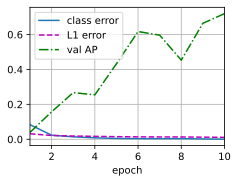

In [32]:
train_model(model, train_loader, val_loader, num_epochs=10, lr=1e-3, weight_decay=1e-4, step_size=8, gamma=0.1)

(extract the exact mAP)

In [48]:
ap_calculator = APCalculator(val_loader)
ap = ap_calculator.calculate_map(model, nms_threshold=0.5)
print(ap["map_50"].item())

0.7194286584854126


(Based on object_detection day 2)



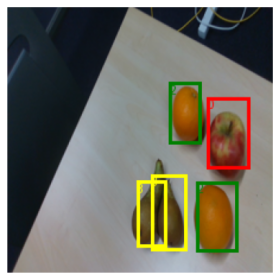

In [50]:
import random
from torchvision.transforms import ToPILImage

img, _ = full_dataset[random.randint(0, len(full_dataset) - 1)] #I chose a random image, so we could inspect different predictions instead of always seeing the same one

boxes, scores, top_class = predict(
    model,
    img.to(device),
    n_classes=num_classes,
    nms_threshold=0.5,
    conf_threshold=0.3,
)

plot_img = plot_bbox(ToPILImage()(img), boxes, top_class.cpu().numpy())
plt.imshow(plot_img)
plt.axis("off")
plt.show()

(the next block of code was added, because the test set has no annotations, so we need a dataset that only loads images for inference)

In [34]:
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, img_folder, transforms=None):
        self.img_folder = img_folder
        self.transforms = transforms
        self.img_files = sorted(
            [os.path.join(img_folder, f) for f in os.listdir(img_folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        )

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transforms:
            img = self.transforms(img)
        return img

    def __len__(self):
        return len(self.img_files)

test_dataset = TestDataset(
    img_folder="fruit-detection-challenge/test",
    transforms=detector_transforms,
)

print(f"Number of test images: {len(test_dataset)}")


Number of test images: 30


## Creating submission `.txt` file
The submission format should be a txt file as follow where predicted boxes are presented as `image_filename, cx, cy, w, h, class_id, confidence. This is an example:

```
color_001.png, 0.9385692477226257, 0.12406756728887558, 0.15019071102142334, 0.22750574350357056, 3, 0.9989498257637024
color_002.png, 0.699505090713501, 0.38808369636535645, 0.25795409083366394, 0.4329442083835602, 2, 0.9999927282333374
color_002.png, 0.8748611807823181, 0.6965410709381104, 0.15483522415161133, 0.2767787575721741, 3, 0.9996340274810791
color_003.png, 0.5620995163917542, 0.36693891882896423, 0.3271831274032593, 0.43740174174308777, 2, 0.9999911785125732
color_004.png, 0.7048399448394775, 0.5529986619949341, 0.19585376977920532, 0.29669857025146484, 3, 0.9999991655349731
color_004.png, 0.6807190775871277, 0.18781284987926483, 0.18665297329425812, 0.3028806447982788, 3, 0.9999967813491821
color_004.png, 0.8595101237297058, 0.360429972410202, 0.2043967992067337, 0.3125438988208771, 3, 0.9999872446060181
color_005.png, 0.5389502048492432, 0.5513347387313843, 0.18025022745132446, 0.3195890188217163, 3, 0.9999912977218628
color_005.png, 0.5121865272521973, 0.2852896749973297, 0.1954585462808609, 0.274965763092041, 3, 0.9999532699584961
color_006.png, 0.25715094804763794, 0.9217860102653503, 0.17427219450473785, 0.1739407777786255, 2, 0.9999980926513672
````

We provide you some starting code for this in the next cell.


In [44]:
from object_detection_utils import predict

def predict_test_submission(model, test_dataset, output_txt_path, img_size, score_threshold=0.3, nms_threshold=0.3):
    model.eval()
    model.to(device)

    with open(output_txt_path, "w") as out_file:
        for i in range(len(test_dataset)):
            img_path = test_dataset.img_files[i]
            pil_img = Image.open(img_path).convert("RGB")
            tensor_img = test_dataset.transforms(pil_img).to(device)

            boxes, scores, top_class = predict(
                model,
                tensor_img,
                n_classes=num_classes,
                nms_threshold=nms_threshold,
                conf_threshold=score_threshold,
            )

            file_name = os.path.basename(img_path)

            img_w, img_h = pil_img.size  # IMPORTANT: real image size

            for box, lbl, sc in zip(boxes, top_class, scores):
                cx, cy, w, h = box.tolist()

                cx /= img_w
                cy /= img_h
                w /= img_w
                h /= img_h


                cx = max(0, min(1, cx))
                cy = max(0, min(1, cy))
                w = max(0, min(1, w))
                h = max(0, min(1, h))

                out_file.write(f"{file_name}, {cx}, {cy}, {w}, {h}, {lbl.item()+1}, {sc.item()}\n")

    print(f"Predictions saved to {output_txt_path}")

## Testing your code before submitting using the validation set
We provide you with the validation set in the same `.txt` format used in the submission file. Check it here `fruit-detection-challenge/detection/annotations/val.txt`.

We also provide you with the code that the submission server uses to calculate AP performance. You can find it in `object_detection_utils.py` with name `FileBasedAPCalculator`. Let's see how to use it.

Let's first create a noisy version of our ground truth `val.txt` for this demonstration.

In [45]:
import numpy as np

def add_noise_to_box(box_coords, noise_factor=0.1):
    noisy_box = []
    for coord in box_coords:
        noisy_coord = np.random.normal(loc=coord, scale=noise_factor * coord)
        noisy_box.append(max(0, min(noisy_coord, 1)))  # Ensure the values are within [0, 1]
    return noisy_box

def remove_random_predictions(predictions, removal_fraction=0.2):
    num_predictions = len(predictions)
    indices_to_remove = np.random.choice(num_predictions, size=int(removal_fraction * num_predictions), replace=False)
    remaining_predictions = [pred for i, pred in enumerate(predictions) if i not in indices_to_remove]
    return remaining_predictions

def process_predictions(file_path):
    predictions = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            image_name = parts[0]
            box_coords = list(map(float, parts[1:5]))
            class_id = int(parts[5])
            confidence = 1.0
            predictions.append((image_name, *box_coords, class_id, confidence))

    noisy_predictions = []
    for pred in predictions:
        image_name, x_center, y_center, width, height, class_id, conf = pred
        noisy_box = add_noise_to_box([x_center, y_center, width, height], 0.05)
        noisy_predictions.append((image_name, *noisy_box, class_id, conf))

    remaining_predictions = remove_random_predictions(noisy_predictions, 0.1)

    return remaining_predictions

def save_processed_predictions(predictions, output_file_path):
    with open(output_file_path, 'w') as f:
        for pred in predictions:
            line = ','.join(map(str, pred))
            f.write(line + '\n')



In [46]:
predict_test_submission(
    model,
    test_dataset,
    "submission_one_step_raw.txt",
    img_size=img_size,
    score_threshold=0.3,
    nms_threshold=0.3,
)

processed_predictions = process_predictions("submission_one_step_raw.txt")
save_processed_predictions(processed_predictions, "submission_one_step_noisy.txt")

print("Saved final noisy submission to submission_one_step_noisy.txt")


Predictions saved to submission_one_step_raw.txt
Saved final noisy submission to submission_one_step_noisy.txt
